In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Problem 1
See slide 1 of homework4 google slides for location of horizontal contact

In [2]:
data_path = 'p1_data.csv'
p1_df = pd.read_csv(data_path)

In [29]:
# use eq 3.21 pg 74
revers_dist = p1_df.dist_from_shot_m[::-1]

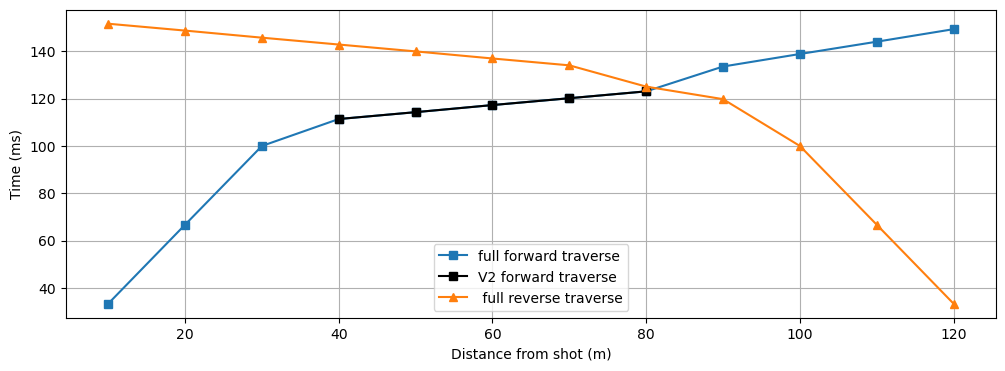

In [5]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(p1_df.dist_from_shot_m, p1_df.forward_traverse_ms, marker='s',label='full forward traverse')
ax.plot(p1_df.dist_from_shot_m[3:8], p1_df.forward_traverse_ms[3:8], marker='s',color='k',label='V2 forward traverse')
ax.plot(p1_df.dist_from_shot_m[::-1], p1_df.reverse_traverse_ms, marker='^',label=' full reverse traverse')
ax.set_xlabel('Distance from shot (m)')
ax.set_ylabel("Time (ms)")
ax.legend(loc='best')
plt.grid(True)
plt.show()

In [6]:
# Forward velocities
v_2, t2_int = np.polyfit(p1_df.dist_from_shot_m[3:7], p1_df.forward_traverse_ms[3:7], 1)
# direct wave
v_1, t1_int = np.polyfit(p1_df.dist_from_shot_m[0:2], p1_df.forward_traverse_ms[0:2], 1)
# second layer
v_3, t3_int = np.polyfit(p1_df.dist_from_shot_m[8:11], p1_df.forward_traverse_ms[8:11], 1)


In [31]:
print(f"velocity of direct wave: {v_1*1000:.2f} m/s. Time intercept: {t2_int:.2f} ms.")
print(f"velocity of layer 1: {v_2*1000:.2f} m/s. Time-axis intercet: {t1_int} ms.")

print(f"velocity of layer 2: {v_3*1000:.2f} m/s. Time intercept: {t3_int:.2f} ms.")

velocity of direct wave: 3340.00 m/s. Time intercept: 99.63 ms.
velocity of layer 1: 294.00 m/s. Time-axis intercet: -0.10000000000000392 ms.
velocity of layer 2: 525.00 m/s. Time intercept: 86.37 ms.


In [ ]:
# thickness h1
h1 = (t2_int / 2) * (v_2 * v_1) / np.sqrt(np.square(v_1) - np.square(v_2))
print(f"thickness of horizontal top layer: {h1:.2f} m")

thickness of horizontal top layer: 14.70 m


# Problem 2

There appears to be three layers based on the slope breaks in the forward and reverse traverses. The third interface is much more subtle in the traverse that starts on the right. The layers are dipping because direct waves have different arrival times. The dip direction is right (higher) to left (lower) because the direct wave arrives earlier in the traverse that starts on the left, so this traverse is going up dip.

# Problem 3

In [9]:
p3_path = 'p3_data.csv'
p3_df = pd.read_csv(p3_path)

In [10]:
# Forward velocities

# direct wave
v_direct, to_direct = np.polyfit(p3_df.distance_m[0:8], p3_df.fwd_traverse_ms[0:8], 1)

v_head, to_head = np.polyfit(p3_df.distance_m[9:11], p3_df.fwd_traverse_ms[9:11], 1)


In [ ]:
v_direct_sec = (1 / v_direct) * 1000
v_head_sec = (1 / v_head) * 1000
print(f"velocity of direct wave: {v_direct_sec:.0f} m/s. Time-axis intercet: {to_direct:.2f} ms.")
print(f"velocity of head wave: {v_head_sec:.0f} m/s. Time-axis intercet: {to_head:.2f} ms.")

velocity of direct wave: 1804 m/s. Time-axis intercet: 0.03 ms.
velocity of head wave: 5556 m/s. Time-axis intercet: 18.80 ms.


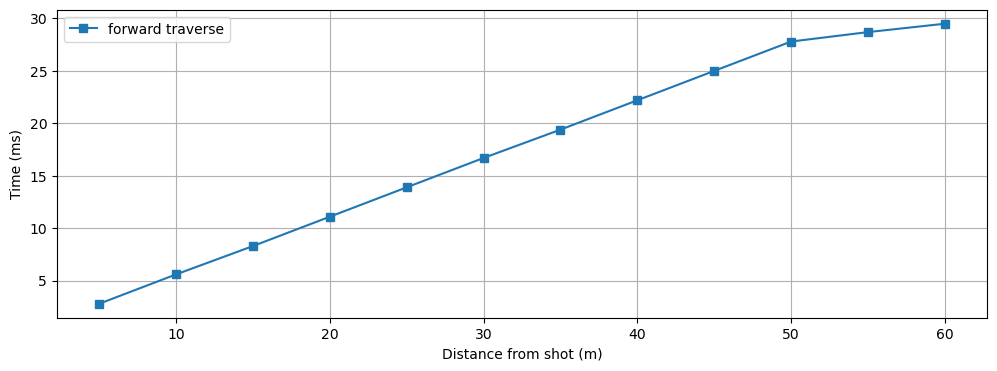

In [12]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(p3_df.distance_m, p3_df.fwd_traverse_ms, marker='s',label='forward traverse')
#ax.plot(p3_df.dist_from_shot_m[3:8], p3_df.forward_traverse_ms[3:8], marker='s',color='k',label='V2 forward traverse')
#ax.plot(p3_df.dist_from_shot_m[::-1], p3_df.reverse_traverse_ms, marker='^',label=' full reverse traverse')
ax.set_xlabel('Distance from shot (m)')
ax.set_ylabel("Time (ms)")
ax.legend(loc='best')
plt.grid(True)
plt.show()

In [13]:
# two-layer problem
h1 = ((to_head/1000) / 2) * ((v_head_sec * v_direct_sec) / np.sqrt(np.square(v_head_sec) - np.square(v_direct_sec)))
print(f'thickness with no well log data: {h1:.2f} m')

thickness with no well log data: 17.93 m


In [14]:
v_low = 1200
h_1 = 3

h2 = (to_head - (2 * h_1 * np.sqrt(np.square(v_head_sec) - np.square(v_direct_sec) ) / (v_head_sec * v_direct_sec)) * ((v_head_sec * v_low) / (2 * np.sqrt(np.square(v_head_sec) - np.square(v_low)))))
p_error = np.abs(h1 - h2) / h2
print(f'depth to bedrock with well log info: {h2:.2f} m')
print(f'percentage error: {p_error:.0%}')


depth to bedrock with well log info: 16.87 m
percentage error: 6%


## Problem 4

In [15]:
p4_path = 'p4_data.csv'
p4_df = pd.read_csv(p4_path)

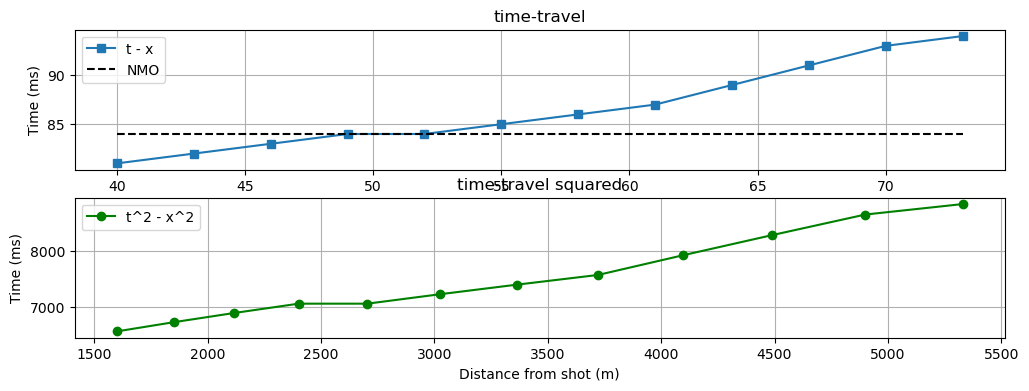

In [16]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,4))
ax1.plot(p4_df.x, p4_df.t, marker='s',label='t - x')
ax1.hlines(p4_df.t[3], p4_df.x.min(), p4_df.x.max(), colors='k',linestyles='--', label='NMO')
ax1.set_xlabel('Distance from shot (m)')
ax1.set_ylabel("Time (ms)")
ax1.legend(loc='best')
ax1.set_title('time-travel')
ax1.grid(True)

ax2.plot(np.square(p4_df.x), np.square(p4_df.t), marker='o',color='g',label='t^2 - x^2')
ax2.set_xlabel('Distance from shot (m)')
ax2.set_ylabel("Time (ms)")
ax2.legend(loc='best')
ax2.set_title('time-travel squared')
ax2.grid(True)

plt.show()

In [17]:
# reflection travel times squared
t_sqr = np.square(p4_df.t[4:13])
x_sqr = np.square(p4_df.x[4:13])

v_sqr, to_sqr = np.polyfit(x_sqr, t_sqr, 1)
v1 = np.sqrt(1/v_sqr)
to = np.sqrt(to_sqr)
print(f'velocity: {v1:.2f} m/ms, t-intercept: {to:.2f} ms')

velocity: 1.18 m/ms, t-intercept: 70.87 ms


In [18]:
h_1 = v1 * to / 2
print(f"thickness: {h1:.2f} m")

thickness: 17.93 m


## Problem 5

In [19]:
def compute_v_rms(t_ms, x_m):
    """ find the slope and intercept of time-travel plot, then convert slope to velocity in m/ms"""
    v_square, to_square = np.polyfit(np.square(x_m), np.square(t_ms), 1)
    v_rms = np.sqrt(1/v_square)
    t_on = np.sqrt(to_square)
    return (v_rms, t_on)

In [20]:
x = [418, 370, 322, 274, 276, 178, 130, 82, 34]
rflct_1 = [440, 435, 425, 422, 420, 415, 412, 410, 402]

In [21]:
v1_rms, to_1 = compute_v_rms(rflct_1, x)
print(f'RMS velocity of reflector 1: {v1_rms:.2f} m/ms, t-intercept reflector 1: {to_1:.2f} ms')

RMS velocity of reflector 1: 2.47 m/ms, t-intercept reflector 1: 406.52 ms


In [22]:
rflct_2 = [492, 485, 477, 472, 469, 460, 455, 455, 450]
v2_rms, to_2 = compute_v_rms(rflct_2, x)
print(f'RMS velocity of reflector 2: {v2_rms:.2f} m/ms, t-intercept reflector 2: {to_2:.2f} ms')
rflct_3 = [638, 632, 630, 625, 622, 621, 618, 618, 621]
v3_rms, to_3 = compute_v_rms(rflct_3, x)
print(f'RMS velocity of reflector 3: {v3_rms:.2f} m/ms, t-intercept reflector 3: {to_3:.2f} ms')

RMS velocity of reflector 2: 2.12 m/ms, t-intercept reflector 2: 451.72 ms
RMS velocity of reflector 3: 2.71 m/ms, t-intercept reflector 3: 617.44 ms


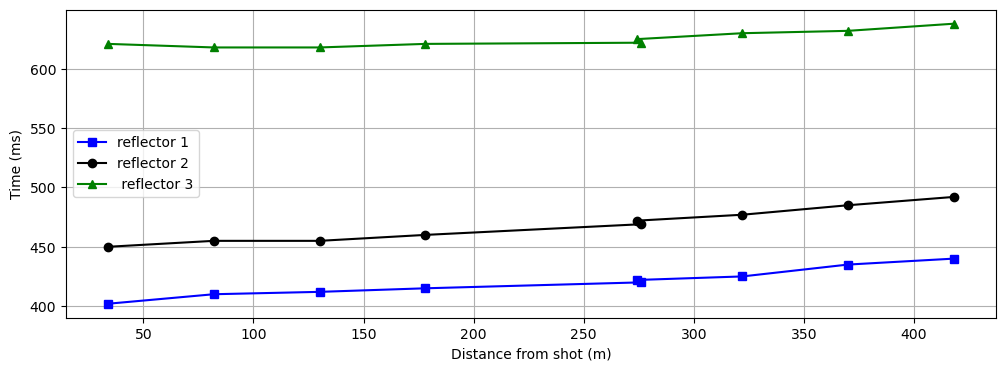

In [23]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(x, rflct_1, marker='s',color='b', label='reflector 1')
ax.plot(x, rflct_2, marker='o',color='k', label='reflector 2')
ax.plot(x, rflct_3, marker='^',color='g', label=' reflector 3')
ax.set_xlabel('Distance from shot (m)')
ax.set_ylabel("Time (ms)")
ax.legend(loc='best')
plt.grid(True)
plt.show()

In [24]:
# interval velocity
def compute_v_interval(v_nrms, t_on, v_n1, t_on1):
    """ compute the interval velocity (m/ms)
        Inputs:
            v_nrms: RMS velocity of the lower layer, n
            t_on: intercept time of lower layer, n
            v_n1: RMS velocity of the upper layer, n-1
            t_on1: intercept time of the upper layer n-1
        returns the interval velocity of the lower layer, n
        """

    # I included abs because the interval velocity of second layer was negative. The v2_rms is less than v1_rms. Maybe due to poor picks?
    numerator = np.abs((np.square(v_nrms) * (t_on)) - (np.square(v_n1) * (t_on1)))
    demoninator = t_on - t_on1
    v_n = numerator / (demoninator)
    return np.sqrt(v_n)

In [25]:
# calculate interval velocities
v1_interval = v1_rms
v2_interval = compute_v_interval(v_2, to_2, v_1, to_1)
v3_interval = compute_v_interval(v_3, to_3, v_2, to_2)

In [26]:
print(f"interval velocity reflector 1: {v1_interval * 1000} m/s")
print(f"interval velocity reflector 2: {v2_interval * 1000} m/s")
print(f"interval velocity reflector 3: {v3_interval * 1000} m/s")

interval velocity reflector 1: 2468.436428676716 m/s
interval velocity reflector 2: 9973.572221400367 m/s
interval velocity reflector 3: 889.5653539401297 m/s


In [27]:
# calculate thickness
h1 = 0.5 * v1_interval * to_1
h2 = 0.5 * v2_interval * (to_2 - to_1)
h3 = 0.5 * v3_interval * (to_3 - to_1)

In [32]:
# These values still seem too big...
print(f"thickness unit 1: {h1:.0f} m")
print(f"thickness unit 2: {h2:.0f} m")
print(f"thickness unit 3: {h3:.0f} m")

thickness unit 1: 502 m
thickness unit 2: 225 m
thickness unit 3: 94 m
